In [6]:
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.io as sio
import os
import matplotlib.pyplot as plt
# import rpeaks as rp

In [7]:
ecg_path = r"D:\hongsi\SKNA_transform\csv\07503322_filtered.csv"
df = pd.read_csv(ecg_path)
fs = 500  # 取樣頻率500Hz

time = df['Time'].values
ecg_signal_1 = df['Channel_1'].values
ecg_signal_2 = df['Channel_2'].values

# print(f"Time shape: {time.shape}")
# print(f"ECG signal shape: {ecg_signal_1.shape}")
# print(f"ECG signal shape: {ecg_signal_2.shape}")

(316546, 1)


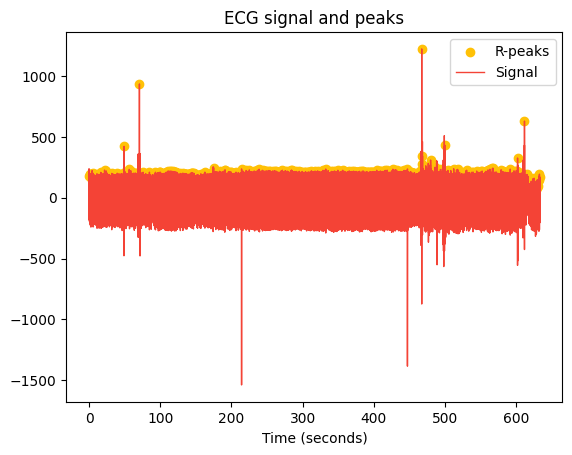

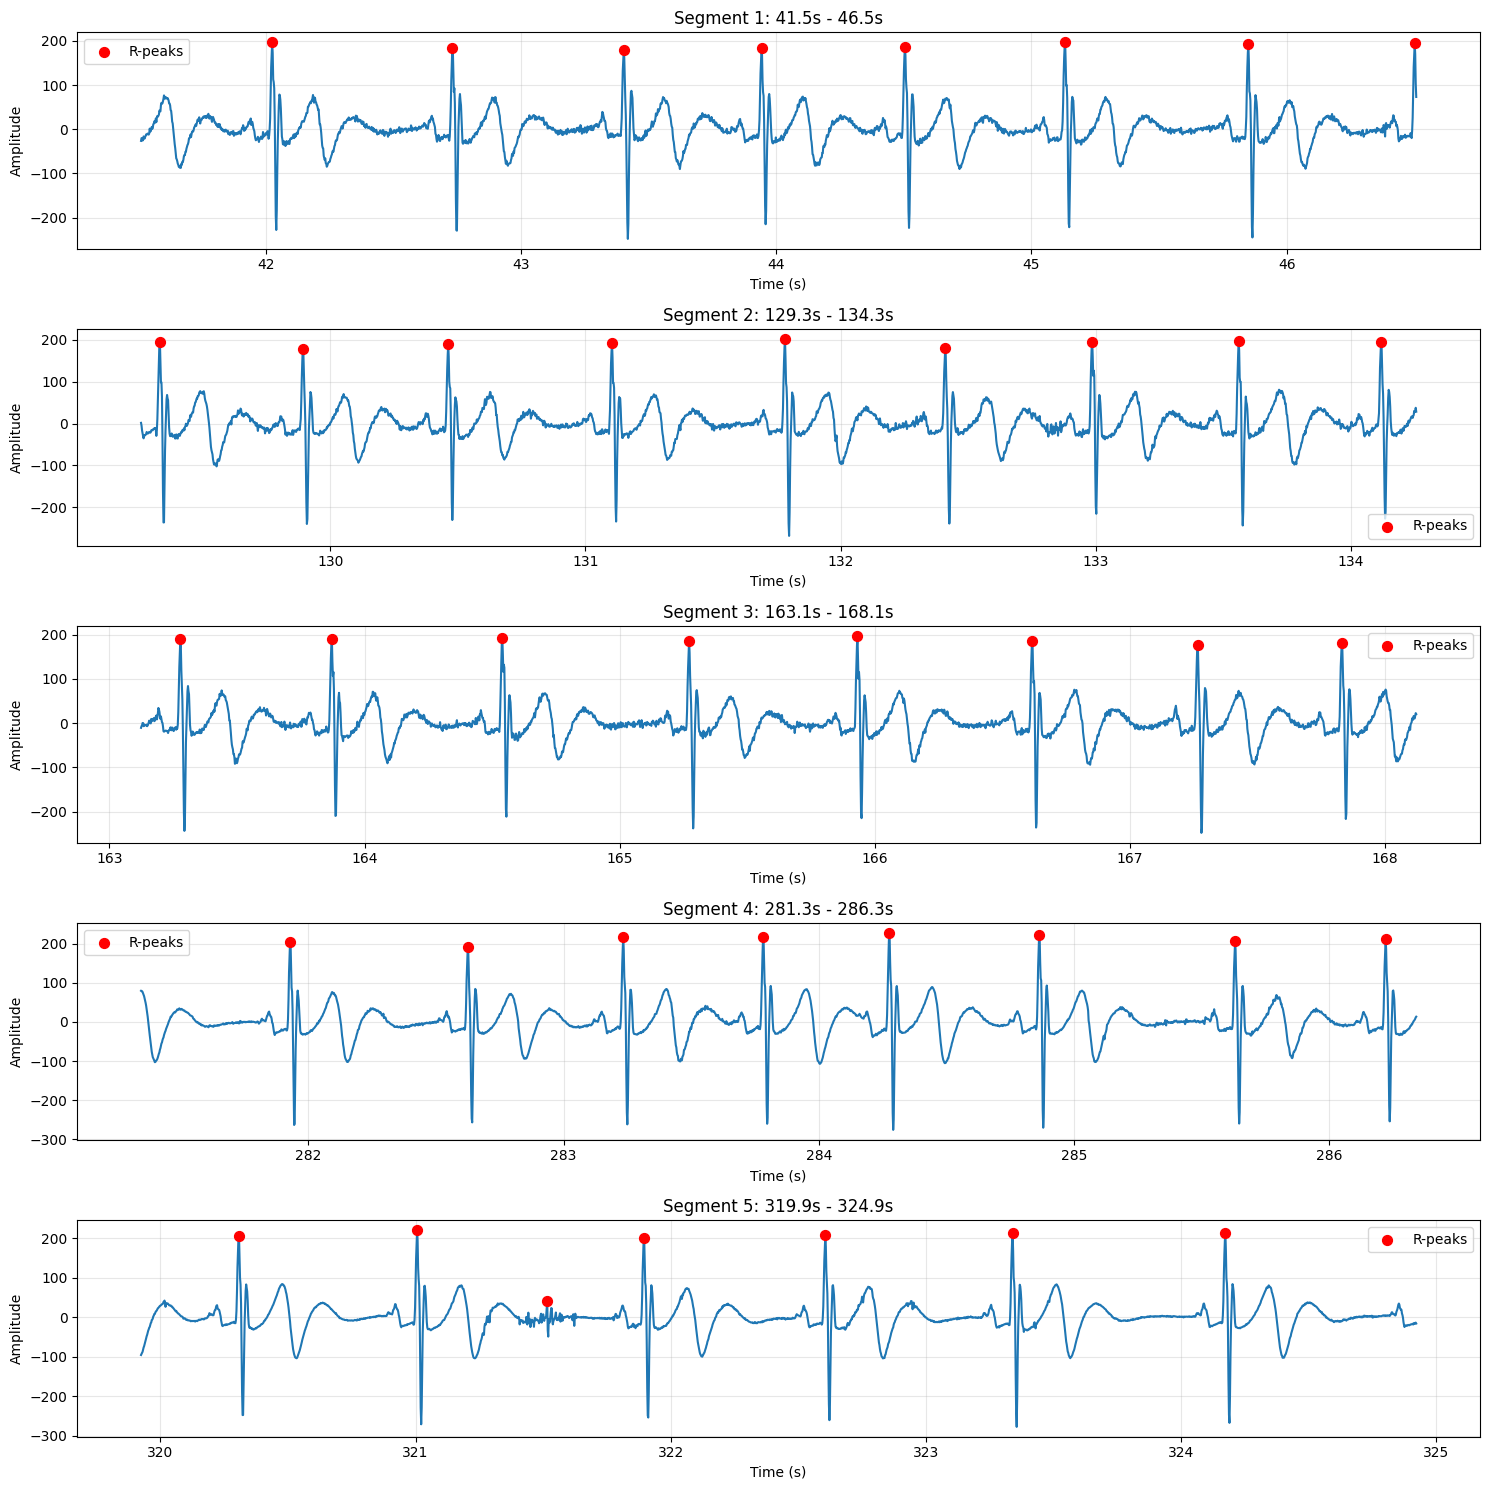

Average Heart Rate: 97.23 bpm
Min Heart Rate: 19.95 bpm
Max Heart Rate: 197.37 bpm
Std Heart Rate: 18.60 bpm


In [28]:
import rpeaks as rp
import neurokit2 as nk


signals, info = nk.ecg_peaks(ecg_signal_1, sampling_rate=fs, show=True)
print(signals.shape)

rpeaks = info['ECG_R_Peaks']
# Select 5 random segments of 10 seconds each
segment_duration = 5  # Duration in seconds
np.random.seed(42)  # For reproducible results
total_samples = len(ecg_signal_1)
max_start = total_samples - segment_duration * fs

start_times = np.sort(np.random.choice(max_start, 5, replace=False))

fig, axes = plt.subplots(5, 1, figsize=(15, 15))

for i, start_idx in enumerate(start_times):
    end_idx = start_idx + segment_duration * fs
    time_segment = time[start_idx:end_idx]
    ecg_segment = ecg_signal_1[start_idx:end_idx]
    
    # Find R-peaks within this segment
    r_peaks_in_segment = rpeaks[(rpeaks >= start_idx) & (rpeaks < end_idx)]
    r_peaks_segment = r_peaks_in_segment - start_idx
    
    axes[i].plot(time_segment, ecg_segment)
    axes[i].scatter(time_segment[r_peaks_segment], ecg_segment[r_peaks_segment], 
                   color='red', s=50, zorder=5, label='R-peaks')
    axes[i].set_title(f'Segment {i+1}: {time_segment[0]:.1f}s - {time_segment[-1]:.1f}s')
    axes[i].set_xlabel('Time (s)')
    axes[i].set_ylabel('Amplitude')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate average heart rate
rr_intervals = np.diff(rpeaks) / fs  # RR intervals in seconds
heart_rate = 60 / rr_intervals  # Convert to beats per minute
average_hr = np.mean(heart_rate)

print(f"Average Heart Rate: {average_hr:.2f} bpm")
print(f"Min Heart Rate: {np.min(heart_rate):.2f} bpm")
print(f"Max Heart Rate: {np.max(heart_rate):.2f} bpm")
print(f"Std Heart Rate: {np.std(heart_rate):.2f} bpm")




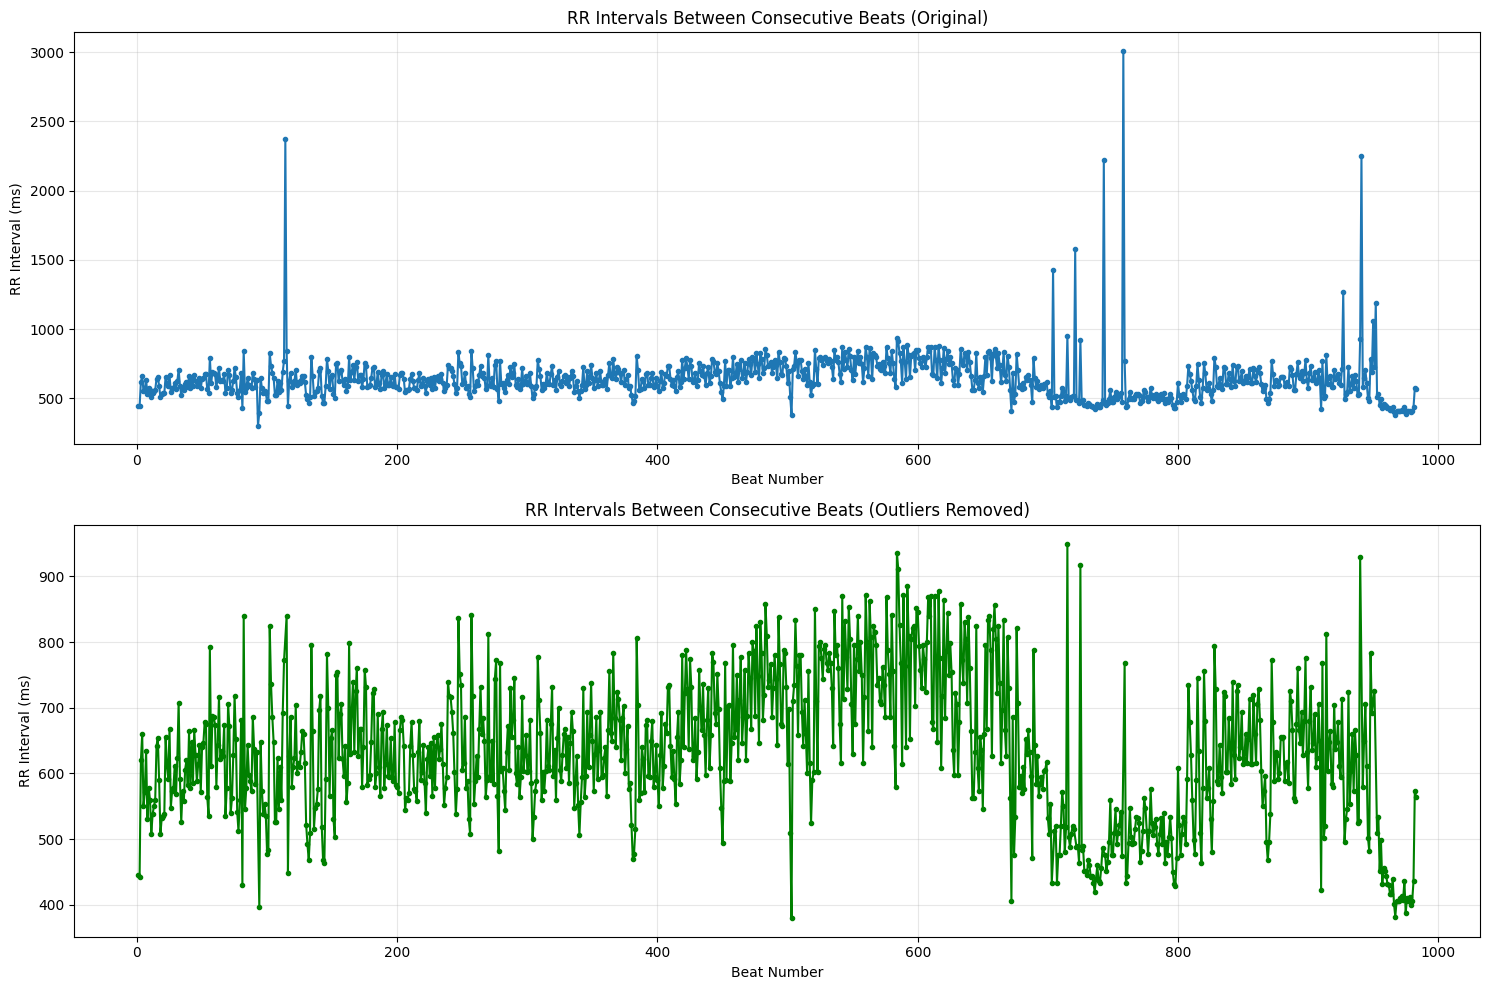


Outlier Removal Statistics:
Original number of RR intervals: 983
Filtered number of RR intervals: 973
Number of outliers removed: 10
Lower bound: 309.25 ms
Upper bound: 977.57 ms

Filtered Heart Rate Statistics:
Average Heart Rate: 97.69 bpm
Min Heart Rate: 63.16 bpm
Max Heart Rate: 157.89 bpm
Std Heart Rate: 17.44 bpm


In [9]:
# Plot RR intervals with beat number on x-axis
plt.figure(figsize=(15, 5))
plt.plot(range(1, len(rr_intervals) + 1), rr_intervals * 1000, marker='o', linestyle='-', markersize=3)
plt.xlabel('Beat Number')
plt.ylabel('RR Interval (ms)')
plt.title('RR Intervals Between Consecutive Beats')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Remove outliers (RR intervals beyond mean ± 2 standard deviations)
mean_rr = np.mean(rr_intervals)
std_rr = np.std(rr_intervals)
lower_bound = mean_rr - 2 * std_rr
upper_bound = mean_rr + 2 * std_rr

# Filter RR intervals
rr_filtered = rr_intervals[(rr_intervals >= lower_bound) & (rr_intervals <= upper_bound)]
beat_numbers_filtered = np.where((rr_intervals >= lower_bound) & (rr_intervals <= upper_bound))[0] + 1

print(f"\nOutlier Removal Statistics:")
print(f"Original number of RR intervals: {len(rr_intervals)}")
print(f"Filtered number of RR intervals: {len(rr_filtered)}")
print(f"Number of outliers removed: {len(rr_intervals) - len(rr_filtered)}")
print(f"Lower bound: {lower_bound * 1000:.2f} ms")
print(f"Upper bound: {upper_bound * 1000:.2f} ms")

# Plot filtered RR intervals
plt.figure(figsize=(15, 5))
plt.plot(beat_numbers_filtered, rr_filtered * 1000, marker='o', linestyle='-', markersize=3)
plt.xlabel('Beat Number')
plt.ylabel('RR Interval (ms)')
plt.title('RR Intervals Between Consecutive Beats (Outliers Removed)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Recalculate statistics without outliers
heart_rate_filtered = 60 / rr_filtered
print(f"\nFiltered Heart Rate Statistics:")
print(f"Average Heart Rate: {np.mean(heart_rate_filtered):.2f} bpm")
print(f"Min Heart Rate: {np.min(heart_rate_filtered):.2f} bpm")
print(f"Max Heart Rate: {np.max(heart_rate_filtered):.2f} bpm")
print(f"Std Heart Rate: {np.std(heart_rate_filtered):.2f} bpm")

,HRV_SD1,HRV_SD2,HRV_SD1SD2,HRV_S,HRV_CSI,HRV_CVI,HRV_CSI_Modified,HRV_PIP,HRV_IALS,HRV_PSS,...,HRV_SampEn,HRV_ShanEn,HRV_FuzzyEn,HRV_MSEn,HRV_CMSEn,HRV_RCMSEn,HRV_CD,HRV_HFD,HRV_KFD,HRV_LZC
0,147.179292,185.032365,0.795425,85554.780639,1.25719,5.639214,930.483508,0.583927,0.581443,0.875887,...,1.263491,7.553354,0.927254,0.566514,1.348408,1.598257,0.986976,1.967262,2.081307,0.900054


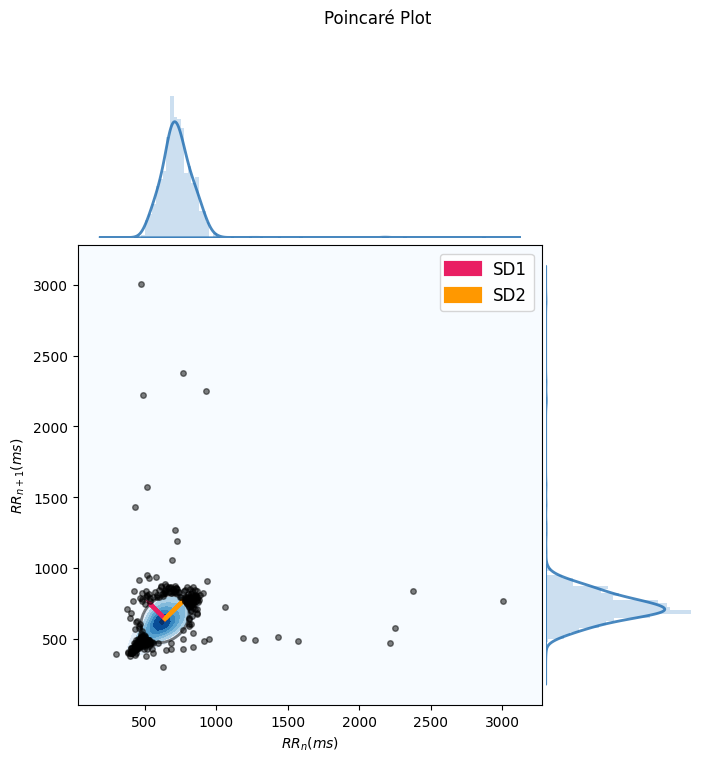

In [29]:
# print(quality_report)
# nk.hrv_frequency(signals, sampling_rate=fs, show=True)
# nk.hrv_time(signals, sampling_rate=fs, show=True)
nk.hrv_nonlinear(signals, sampling_rate=fs, show=True)

